## Phase 1 : Exploration et Préparation

### 1.1 Chargement et Inspection

In [25]:
# Import des bibliothèques
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pathlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score
import cv2
import os


In [26]:
data_dir = pathlib.Path("../data/food-11")

# Vérifier que le dossier existe
if not data_dir.exists():
    raise FileNotFoundError(f"Dataset non trouvé: {data_dir}")

# Les dossiers possibles
train_dir = data_dir / "training"
val_dir = data_dir / "validation"
test_dir = data_dir / "evaluation"

class_names = ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 
               'Meat', 'Noodles/Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable/Fruit']
num_classes = 11

In [27]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print(f"Configuration définie")
print(f"  - Taille des images : {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Batch size : {BATCH_SIZE}")
print(f"  - Nombre de classes : {num_classes}")

Configuration définie
  - Taille des images : 224x224
  - Batch size : 32
  - Nombre de classes : 11


### Visualisation d'Échantillons

Found 9866 files belonging to 11 classes.
Using 8880 files for training.
Found 9866 files belonging to 11 classes.
Using 986 files for validation.
Found 3347 files belonging to 11 classes.
  - Train batches: 278
  - Val batches: 31
  - Test batches: 105


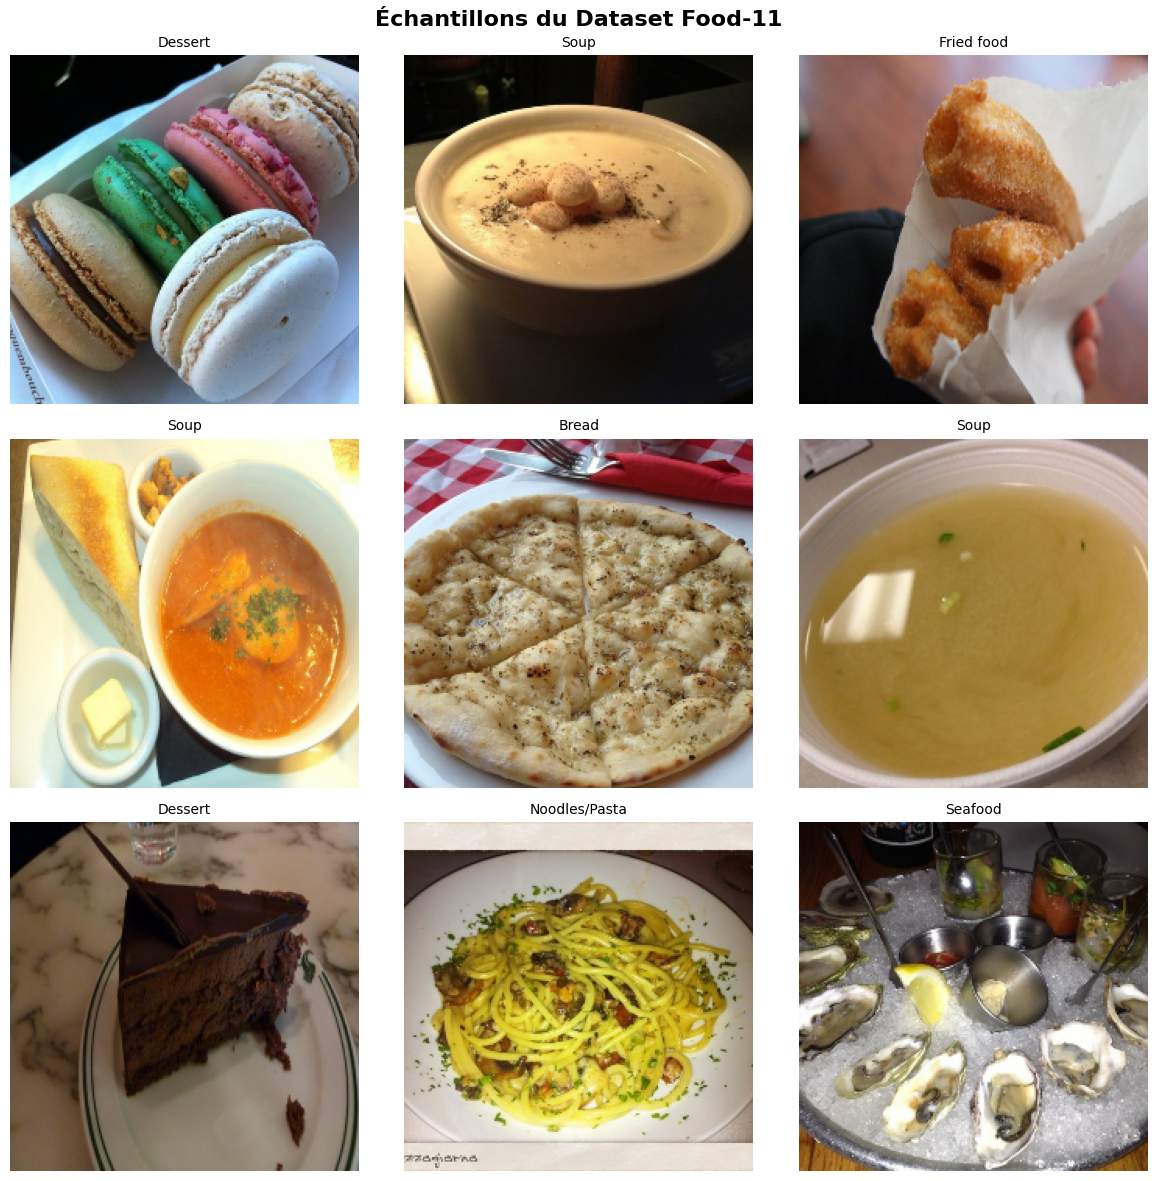

In [ ]:
# Créer datasets avec image_dataset_from_directory
# Dataset de training avec validation split
ds_train_full = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=0.1,
    subset='training'
)

ds_val = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    validation_split=0.1,
    subset='validation'
)

# Dataset de test (si dossier séparé existe)
if test_dir.exists() and test_dir != train_dir:
    ds_test = tf.keras.utils.image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='int',
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        shuffle=False
    )
else:
    # Sinon utiliser validation comme test
    ds_test = ds_val

print(f"  - Train batches: {len(ds_train_full)}")
print(f"  - Val batches: {len(ds_val)}")
print(f"  - Test batches: {len(ds_test)}")

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
fig.suptitle('Échantillons du Dataset Food-11', fontsize=16, fontweight='bold')

for images, labels in ds_train_full.take(1):
    for i in range(9):
        ax = axes[i // 3, i % 3]
        ax.imshow(images[i].numpy().astype('uint8'))
        ax.set_title(f'{class_names[labels[i]]}', fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.show()

### 1.2 Stratégie de Préparation

**Décisions :**
- Taille cible : 224x224 (standard transfer learning, compatible EfficientNetB0)
- Normalisation : Rescaling 0-255 → 0-1
- Data Augmentation : rotation (±15°), flip horizontal, zoom (±10%), contrast (±10%)
- Split validation : 10% du train (~887 images validation, ~7,979 images train final)

In [29]:
# Configuration
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

print(f"  - Taille des images : {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Batch size : {BATCH_SIZE}")

  - Taille des images : 224x224
  - Batch size : 32


In [30]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='data_augmentation')

normalization = layers.Rescaling(1./255)

In [31]:
# Train: avec augmentation
ds_train_final = (
    ds_train_full
    .map(lambda x, y: (normalization(data_augmentation(x, training=True)), y), 
         num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

# Validation: sans augmentation
ds_val = (
    ds_val
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

# Test: sans augmentation
ds_test_prep = (
    ds_test
    .map(lambda x, y: (normalization(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

## Phase 2 : Modélisation

### 2.1 Architecture 1 : CNN Custom (Baseline)

Établir une baseline avec CNN from scratch pour comparer avec transfer learning.

In [32]:
def create_baseline_cnn():
    model = keras.Sequential([
        layers.Conv2D(64, 3, activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.2),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.3),
        
        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Dropout(0.4),

        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='CNN_Baseline')
    
    return model

model_baseline = create_baseline_cnn()
model_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_baseline.summary()

c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │         5,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 509,835 (1.94 MB)

 Trainable params: 508,939 (1.94 MB)

 Non-trainable params: 896 (3.50 KB)

In [33]:
# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('baseline_cnn_food11.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [34]:
EPOCHS_BASELINE = 15

history_baseline = model_baseline.fit(
    ds_train_final,
    epochs=EPOCHS_BASELINE,
    validation_data=ds_val,
    callbacks=callbacks_baseline,
    verbose=1
)


Epoch 1/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2217 - loss: 2.2671
Epoch 1: val_accuracy improved from None to 0.11968, saving model to baseline_cnn_food11.keras

Epoch 1: finished saving model to baseline_cnn_food11.keras
278/278 ━━━━━━━━━━━━━━━━━━━━ 378s 1s/step - accuracy: 0.2658 - loss: 2.1224 - val_accuracy: 0.1197 - val_loss: 3.4107 - learning_rate: 0.0010
Epoch 2/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3263 - loss: 1.9393
Epoch 2: val_accuracy improved from 0.11968 to 0.18256, saving model to baseline_cnn_food11.keras

Epoch 2: finished saving model to baseline_cnn_food11.keras
278/278 ━━━━━━━━━━━━━━━━━━━━ 387s 1s/step - accuracy: 0.3413 - loss: 1.8880 - val_accuracy: 0.1826 - val_loss: 2.4475 - learning_rate: 0.0010
Epoch 3/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3727 - loss: 1.8018
Epoch 3: val_accuracy improved from 0.18256 to 0.34483, saving model to baseline_cnn_food11.keras

Epoch 3: finished saving model to baseline_cnn_

### 2.2 Architecture 2 : Transfer Learning - EfficientNetB0

Utiliser un modèle pré-entraîné ImageNet (comme dans demo05).

In [35]:
from tensorflow.keras.applications import EfficientNetB0

def create_efficientnet_b0():
    # Charger le modèle de base pré-entraîné
    base_model = EfficientNetB0(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    
    # GELER toutes les couches du modèle de base
    base_model.trainable = False
    
    # Construire le modèle complet
    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='EfficientNetB0_Frozen')
    
    return model, base_model

model_eff, base_eff = create_efficientnet_b0()

In [36]:

model_eff.compile(
    optimizer="adam",
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_eff.summary()

Model: "EfficientNetB0_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 11)             │         5,643 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,711,086 (17.97 MB)

 Trainable params: 661,515 (2.52 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [37]:
# Callbacks pour transfer learning
callbacks_transfer = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('efficientnet_b0_food11.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [38]:
# Phase 1: Entraînement avec base gelée
EPOCHS_TRANSFER = 15

history_eff = model_eff.fit(
    ds_train_final,
    epochs=EPOCHS_TRANSFER,
    validation_data=ds_val,
    callbacks=callbacks_transfer,
    verbose=1
)

Epoch 1/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.1393 - loss: 2.3581
Epoch 1: val_accuracy improved from None to 0.13895, saving model to efficientnet_b0_food11.keras

Epoch 1: finished saving model to efficientnet_b0_food11.keras
278/278 ━━━━━━━━━━━━━━━━━━━━ 65s 216ms/step - accuracy: 0.1445 - loss: 2.3335 - val_accuracy: 0.1389 - val_loss: 2.3016 - learning_rate: 0.0010
Epoch 2/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.1423 - loss: 2.3106
Epoch 2: val_accuracy did not improve from 0.13895
278/278 ━━━━━━━━━━━━━━━━━━━━ 59s 211ms/step - accuracy: 0.1459 - loss: 2.3086 - val_accuracy: 0.1389 - val_loss: 2.2975 - learning_rate: 0.0010
Epoch 3/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.1549 - loss: 2.3044
Epoch 3: val_accuracy did not improve from 0.13895
278/278 ━━━━━━━━━━━━━━━━━━━━ 60s 214ms/step - accuracy: 0.1546 - loss: 2.3066 - val_accuracy: 0.1389 - val_loss: 2.2961 - learning_rate: 0.0010
Epoch 4/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 

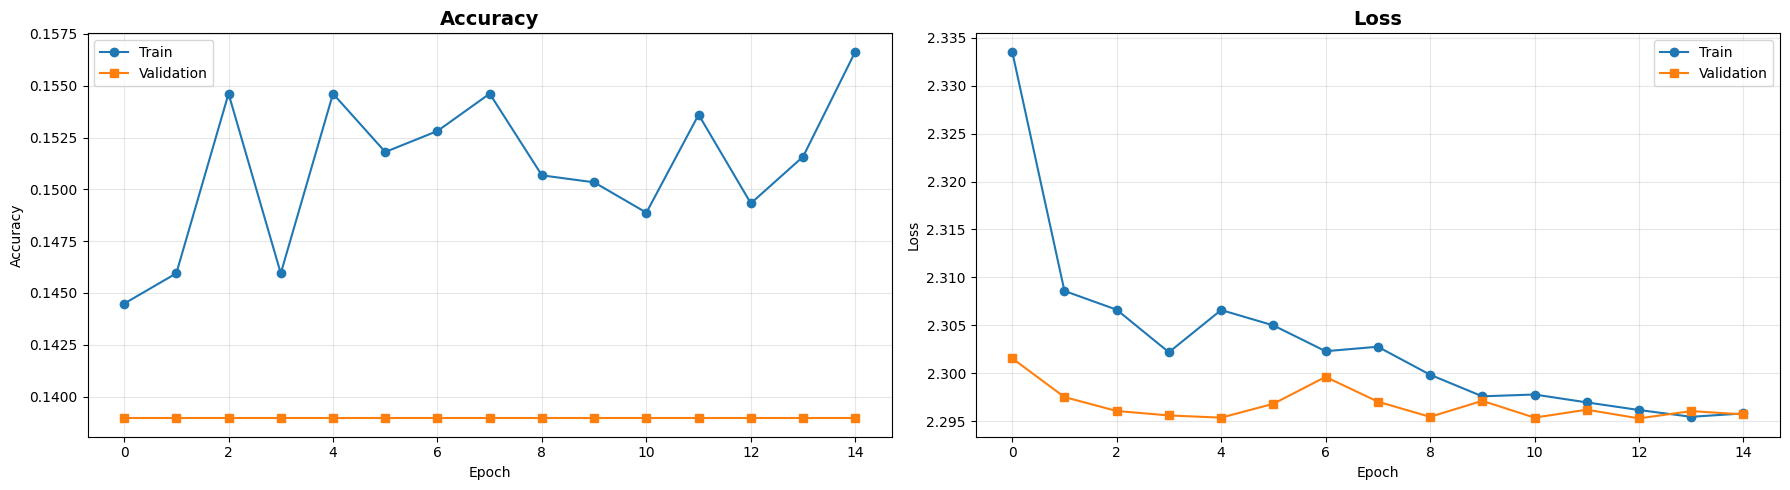

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Accuracy
axes[0].plot(history_eff.history['accuracy'], label='Train', marker='o')
axes[0].plot(history_eff.history['val_accuracy'], label='Validation', marker='s')
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_eff.history['loss'], label='Train', marker='o')
axes[1].plot(history_eff.history['val_loss'], label='Validation', marker='s')
axes[1].set_title('Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Phase 3 : Évaluation

### 4.1 Métriques Globales

In [47]:
test_loss, test_acc = model_baseline.evaluate(ds_test_prep, verbose=1)

print(f"Test Accuracy {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 199ms/step - accuracy: 0.5883 - loss: 1.2663
Test Accuracy 0.5883 (58.83%)
Test Loss: 1.2663


In [48]:
y_pred_proba = model_baseline.predict(ds_test_prep, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# Récupérer les vrais labels
y_true = np.concatenate([y for x, y in ds_test_prep], axis=0)

print(f"  - Nombre de prédictions : {len(y_pred)}")
print(f"  - Nombre de labels réels : {len(y_true)}")

105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 199ms/step
  - Nombre de prédictions : 3347
  - Nombre de labels réels : 3347


### 4.2 Analyse des Erreurs

In [49]:
# Accuracy par classe
class_accuracies = []
for i in range(num_classes):
    mask = (y_true == i)
    if mask.sum() > 0:
        acc = (y_pred[mask] == y_true[mask]).mean()
        class_accuracies.append((class_names[i], acc, i))

# Trier par accuracy
class_accuracies.sort(key=lambda x: x[1], reverse=True)

print("CLASSES FACILES")
for i, (name, acc, idx) in enumerate(class_accuracies[:6]):
    print(f"{i+1:2}. {name:30} : {acc*100:5.2f}%")

print("CLASSES DIFFICILES")
for i, (name, acc, idx) in enumerate(class_accuracies[-5:][::-1]):
    print(f"{i+1:2}. {name:30} : {acc*100:5.2f}%")

CLASSES FACILES
 1. Soup                           : 84.60%
 2. Fried food                     : 79.79%
 3. Vegetable/Fruit                : 77.92%
 4. Meat                           : 70.60%
 5. Egg                            : 57.01%
 6. Noodles/Pasta                  : 48.30%
CLASSES DIFFICILES
 1. Dairy product                  : 27.03%
 2. Rice                           : 29.17%
 3. Bread                          : 36.41%
 4. Seafood                        : 43.56%
 5. Dessert                        : 47.20%


In [50]:
cm = confusion_matrix(y_true, y_pred)
np.fill_diagonal(cm, 0)

top_confusions = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            top_confusions.append((class_names[i], class_names[j], cm[i, j]))

top_confusions.sort(key=lambda x: x[2], reverse=True)

print("TOP 8 CONFUSIONS")
for i, (c1, c2, count) in enumerate(top_confusions[:8]):
    print(f"{i+1:2}. {c1:30} → {c2:30} : {count:3} erreurs")

TOP 8 CONFUSIONS
 1. Dessert                        → Soup                           :  73 erreurs
 2. Bread                          → Egg                            :  69 erreurs
 3. Bread                          → Fried food                     :  56 erreurs
 4. Egg                            → Bread                          :  48 erreurs
 5. Dessert                        → Fried food                     :  45 erreurs
 6. Dessert                        → Egg                            :  44 erreurs
 7. Meat                           → Fried food                     :  41 erreurs
 8. Dessert                        → Meat                           :  38 erreurs


In [54]:
errors_idx = np.where(y_pred != y_true)[0]

print(f"  - Nombre total d'erreurs: {len(errors_idx)} / {len(y_true)}")
print(f"  - Taux d'erreur: {len(errors_idx)/len(y_true)*100:.2f}%")


  - Nombre total d'erreurs: 1378 / 3347
  - Taux d'erreur: 41.17%


## Phase 5 : Interprétabilité

### 5.2 Grad-CAM

Visualiser où le modèle regarde pour prendre sa décision (comme dans demo07).

In [90]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name=None, pred_index=None):
    """Génère une heatmap Grad-CAM (comme demo07) - adapté pour EfficientNetB0"""
    
    # Détecter la dernière couche conv
    if last_conv_layer_name is None:
        try:
            # Pour EfficientNetB0
            base_model = model.get_layer('efficientnetb0')
            last_conv_layer_name = 'top_conv'
        except:
            # Pour baseline CNN - trouver la dernière couche conv
            for layer in reversed(model.layers):
                if 'conv' in layer.name.lower():
                    last_conv_layer_name = layer.name
                    break
    
    # Créer un modèle qui retourne les feature maps de la dernière couche conv + les prédictions
    try:
        # Pour EfficientNetB0 (couche dans un sous-modèle)
        base_model = model.get_layer('efficientnetb0')
        last_conv_output = base_model.get_layer(last_conv_layer_name).output
    except:
        # Pour baseline CNN (couche directe)
        last_conv_output = model.get_layer(last_conv_layer_name).output
    
    # Obtenir l'input du modèle de manière robuste
    try:
        model_inputs = model.input
    except AttributeError:
        # Si model.input n'existe pas, utiliser l'input de la première couche
        try:
            model_inputs = model.layers[0].input
        except:
            # Dernière tentative: créer un Input explicite
            model_inputs = keras.Input(shape=(224, 224, 3))
    
    grad_model = keras.Model(
        inputs=model_inputs,
        outputs=[last_conv_output, model.output]
    )
    
    # Calculer les gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    # Gradients de la classe par rapport aux feature maps
    grads = tape.gradient(class_channel, conv_outputs)
    
    # Pooled gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Pondérer les feature maps
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normaliser
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def superimpose_heatmap(img, heatmap, alpha=0.4):
    """Superpose heatmap sur image (comme demo06)"""
    # Redimensionner heatmap
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Convertir en RGB
    heatmap_colored = plt.cm.jet(heatmap_resized)[:, :, :3]
    heatmap_colored = (heatmap_colored * 255).astype(np.uint8)
    
    # Superposer
    superimposed = cv2.addWeighted(img, 1-alpha, heatmap_colored, alpha, 0)
    return superimposed

AttributeError: The layer CNN_Baseline has never been called and thus has no defined output.

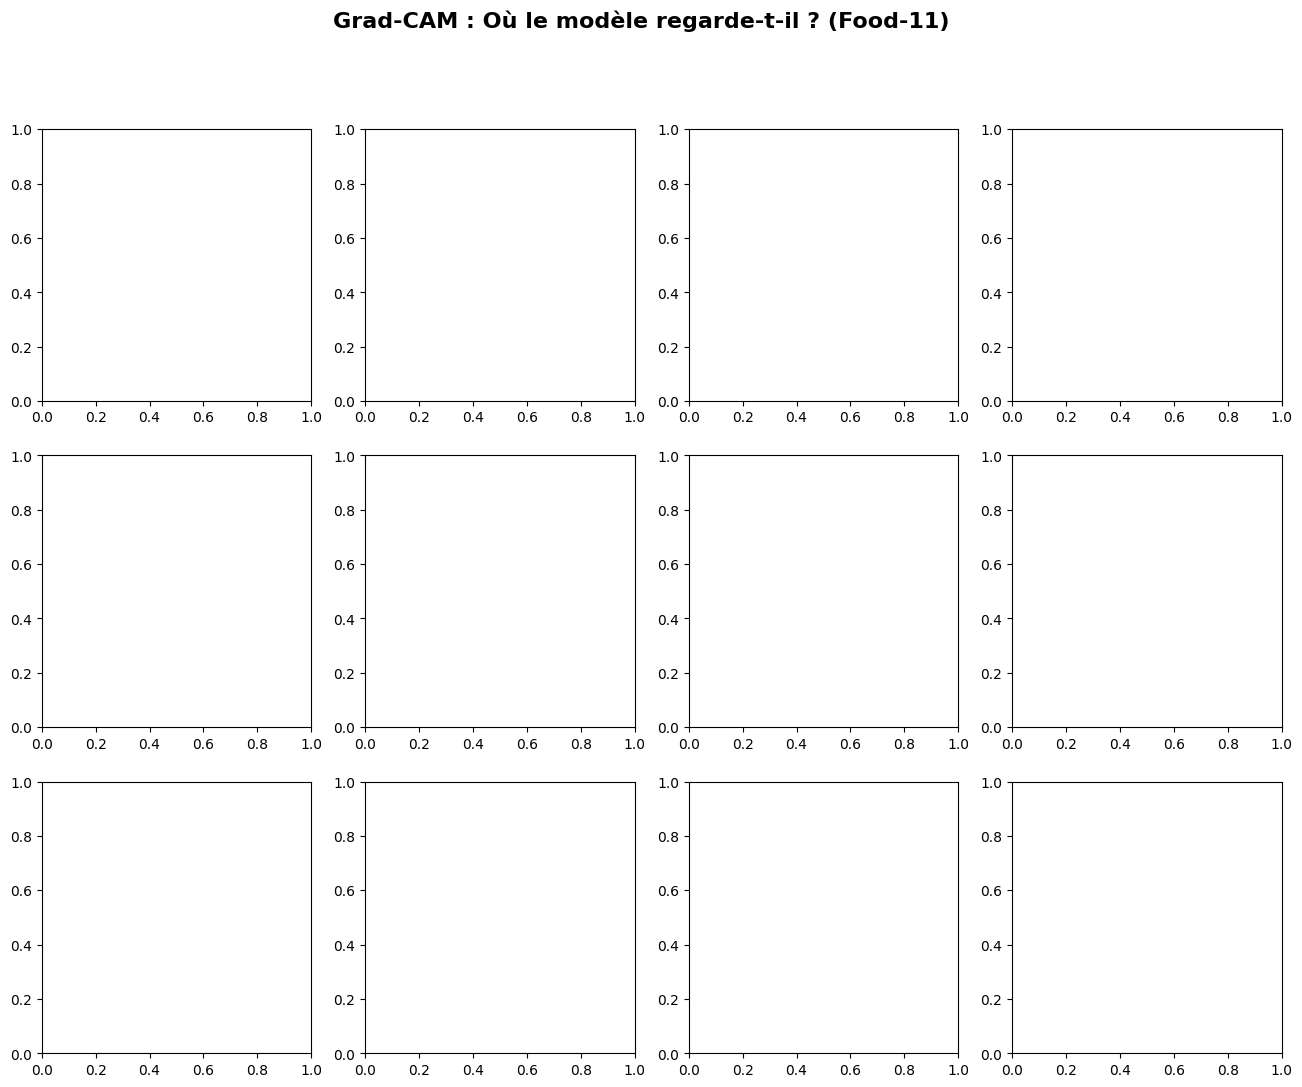

In [91]:
# Construire le modèle AVANT la boucle pour éviter l'erreur "never been called"
dummy_input = np.zeros((1, IMG_SIZE, IMG_SIZE, 3))
_ = model_eff(dummy_input, training=False)

# Grad-CAM sur plusieurs images du test set
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Grad-CAM : Où le modèle regarde-t-il ? (Food-11)', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < 12:
        # Prendre une image du test set
        for idx, (img, label) in enumerate(ds_test.take(i+1)):
            if idx == i:
                # Preprocessing
                img_resized = tf.image.resize(img[0:1], [IMG_SIZE, IMG_SIZE])
                img_array = img_resized / 255.0
                
                # Prédiction
                preds = model_baseline.predict(img_array, verbose=0)
                pred_class = np.argmax(preds[0])
                
                # Grad-CAM - plus besoin de passer le nom de la couche, détection automatique
                heatmap = make_gradcam_heatmap(img_array, model_baseline)
                
                # Superposer
                img_display = img_resized[0].numpy().astype('uint8')
                superimposed = superimpose_heatmap(img_display, heatmap)
                
                # Afficher
                ax.imshow(superimposed)
                ax.set_title(f'Vrai: {class_names[label.numpy()[0]]}\nPréd: {class_names[pred_class]}',
                           fontsize=9)
                ax.axis('off')
                break

plt.tight_layout()
plt.show()

## Phase 6 : Déploiement

### 6.1 Sauvegarde du Modèle

In [ ]:
# Sauvegarder le modèle final
model_baseline.save('best_food11_model.h5')

### 6.2 Pipeline de Prédiction Réutilisable

In [ ]:
class Food11Predictor:
    def __init__(self, model_path):
        self.model = keras.models.load_model(model_path)
        self.class_names = class_names
        self.img_size = IMG_SIZE
    
    def preprocess(self, image_path):
        img = tf.io.read_file(image_path)
        img = tf.image.decode_image(img, channels=3)
        img = tf.image.resize(img, [self.img_size, self.img_size])
        img = tf.cast(img, tf.float32) / 255.0
        return tf.expand_dims(img, 0)
    
    def predict(self, image_path, top_k=3):
        img = self.preprocess(image_path)
        preds = self.model.predict(img, verbose=0)[0]
        
        # Top-K
        top_indices = np.argsort(preds)[-top_k:][::-1]
        results = []
        for idx in top_indices:
            results.append({
                'class': self.class_names[idx],
                'confidence': float(preds[idx])
            })
        
        return results